In [1]:
# Setup
!pip -q install kagglehub wfdb imbalanced-learn

import os
import re
import glob
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageEnhance
from scipy import stats, signal

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import RobustScaler, StandardScaler
from imblearn.over_sampling import RandomOverSampler

import kagglehub
import wfdb

random.seed(7)
np.random.seed(7)

print("Environment ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.1 MB/s eta 0:00:00
Environment ready.


In [2]:
# A1–A4: acquire and inspect the diabetes data

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

try:
    diabetes_dir = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
    candidates = glob.glob(os.path.join(diabetes_dir, "**", "*.csv"), recursive=True)
    diabetes = pd.read_csv(candidates[0])
except Exception:
    public_csv = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    diabetes = pd.read_csv(public_csv, header=None, names=columns)

print("Shape:", diabetes.shape)
display(diabetes.head())
print("\nData types:")
print(diabetes.dtypes)
print("\nDuplicate rows:", diabetes.duplicated().sum())


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Duplicate rows: 0


In [3]:
# A5–A6: convert invalid clinical zeros and impute them

measurement_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

clean_diabetes = diabetes.drop_duplicates().copy()

# A zero is not physiologically plausible for these measurements in this dataset.
clean_diabetes[measurement_cols] = clean_diabetes[measurement_cols].replace(0, np.nan)

missing_report = (
    clean_diabetes.isna().sum()
    .to_frame("missing")
    .assign(percent=lambda x: (100 * x["missing"] / len(clean_diabetes)).round(2))
)

display(missing_report)

for feature in measurement_cols:
    clean_diabetes[feature] = clean_diabetes[feature].fillna(
        clean_diabetes[feature].median()
    )

print("Remaining missing values:", int(clean_diabetes.isna().sum().sum()))


,missing,percent
Pregnancies,0,0.00
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43
DiabetesPedigreeFunction,0,0.00
Age,0,0.00
Outcome,0,0.00


Remaining missing values: 0


In [4]:
# A7: simple plausibility checks

checks = {
    "negative glucose": (clean_diabetes["Glucose"] < 0).sum(),
    "negative blood pressure": (clean_diabetes["BloodPressure"] < 0).sum(),
    "negative BMI": (clean_diabetes["BMI"] < 0).sum(),
    "negative age": (clean_diabetes["Age"] < 0).sum(),
    "negative pregnancies": (clean_diabetes["Pregnancies"] < 0).sum(),
}

pd.Series(checks, name="invalid_count")


,invalid_count
negative glucose,0
negative blood pressure,0
negative BMI,0
negative age,0
negative pregnancies,0


In [5]:
# A8: feature engineering

clean_diabetes["BMI_Group"] = pd.cut(
    clean_diabetes["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Low", "Healthy", "Overweight", "Obesity"]
)

clean_diabetes["Age_Band"] = pd.cut(
    clean_diabetes["Age"],
    bins=[20, 30, 40, 50, np.inf],
    labels=["21-30", "31-40", "41-50", "51+"]
)

clean_diabetes["Glucose_Level"] = pd.cut(
    clean_diabetes["Glucose"],
    bins=[0, 99, 125, np.inf],
    labels=["Normal", "Borderline", "High"]
)

display(clean_diabetes[
    ["Glucose", "BMI", "Age", "BMI_Group", "Age_Band", "Glucose_Level", "Outcome"]
].head())


,Glucose,BMI,Age,BMI_Group,Age_Band,Glucose_Level,Outcome
0,148.0,33.6,50,Obesity,41-50,High,1
1,85.0,26.6,31,Overweight,31-40,Normal,0
2,183.0,23.3,32,Healthy,31-40,High,1
3,89.0,28.1,21,Overweight,21-30,Normal,0
4,137.0,43.1,33,Obesity,31-40,High,1


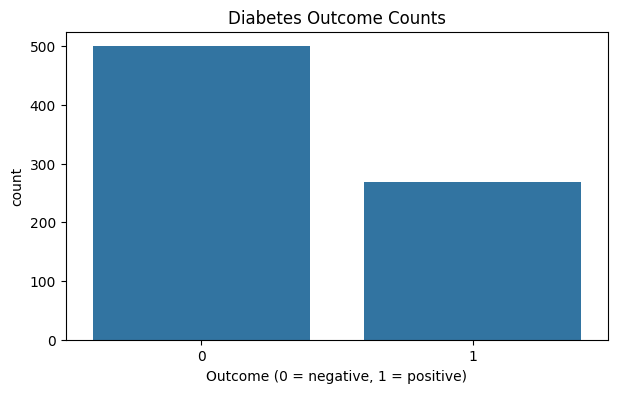

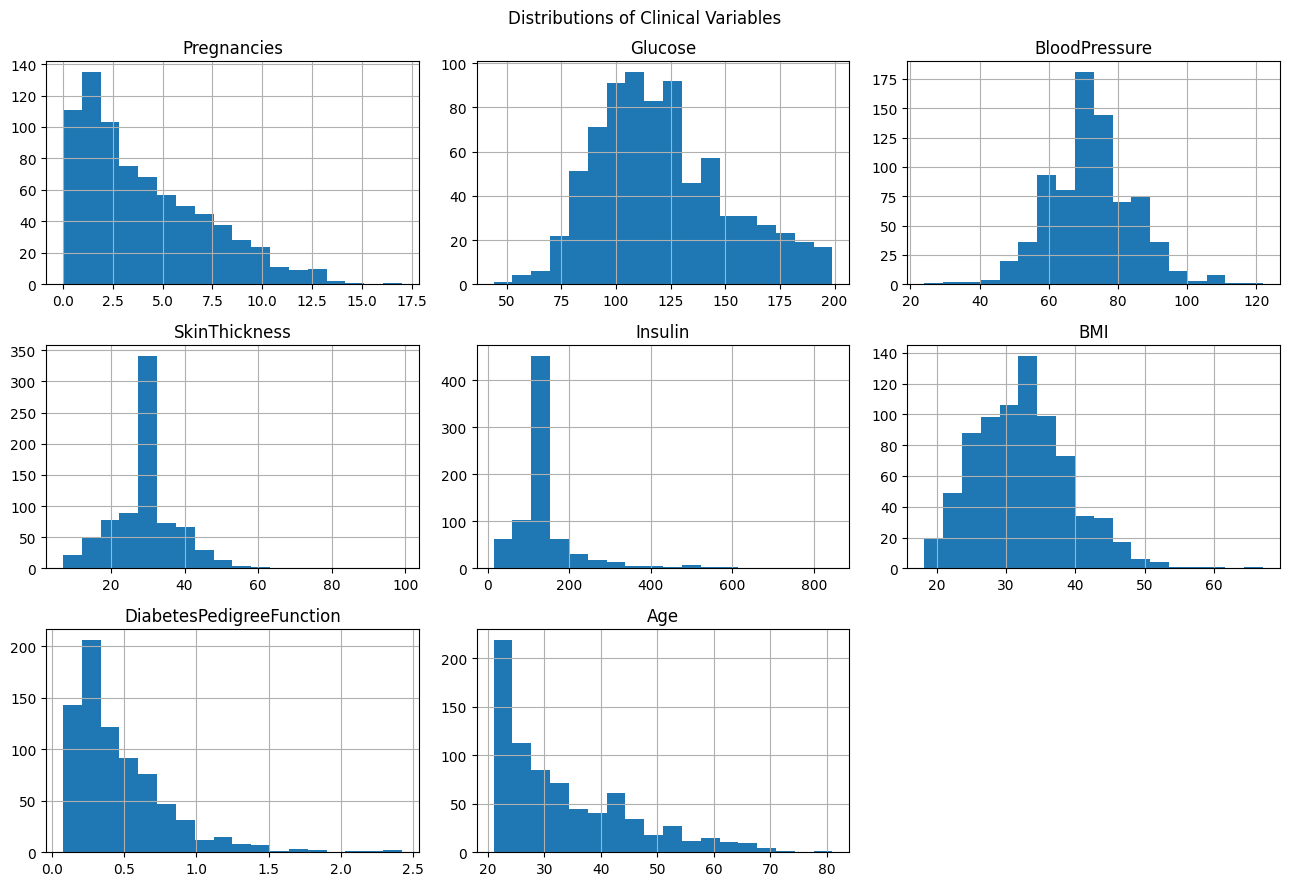

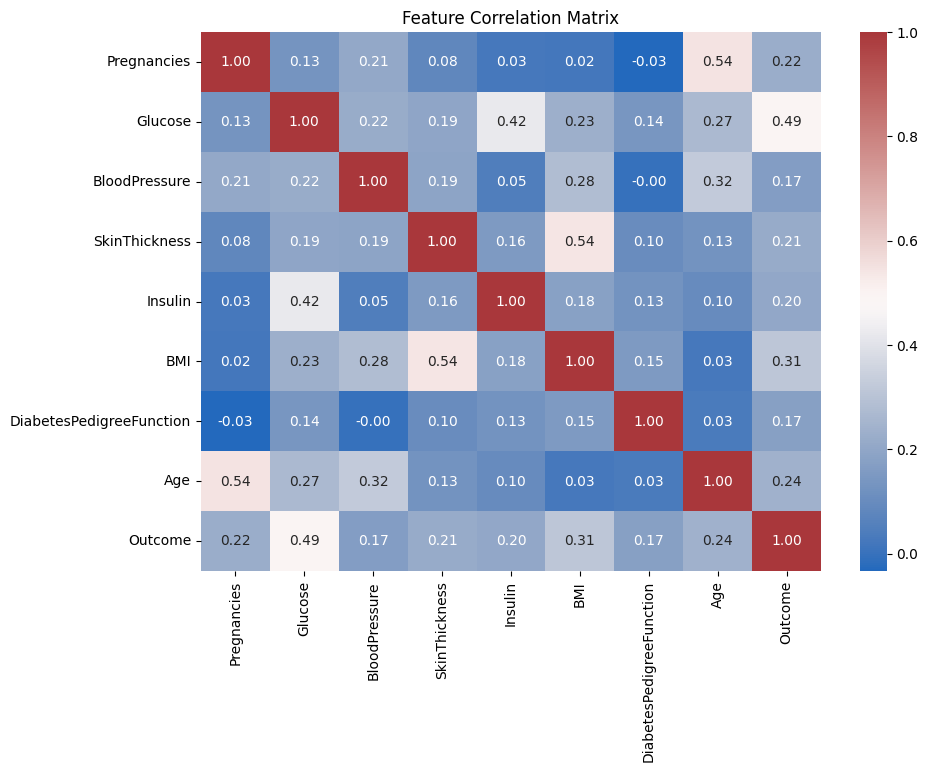

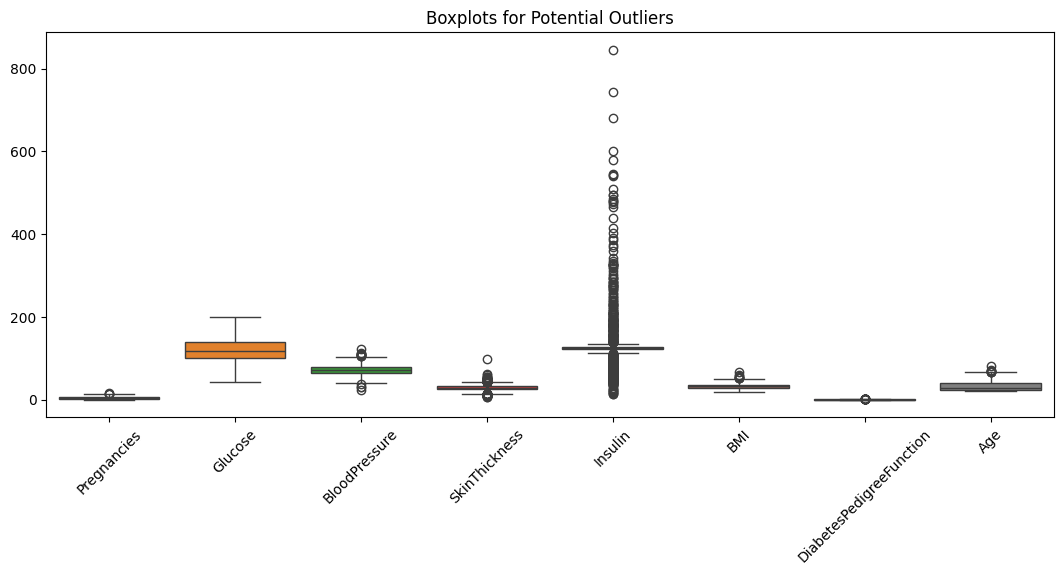

In [6]:
# A9–A12: exploratory analysis

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=clean_diabetes, x="Outcome", ax=ax)
ax.set_title("Diabetes Outcome Counts")
ax.set_xlabel("Outcome (0 = negative, 1 = positive)")
plt.show()

numeric = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

clean_diabetes[numeric].hist(figsize=(13, 9), bins=18)
plt.suptitle("Distributions of Clinical Variables")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(
    clean_diabetes[numeric + ["Outcome"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag"
)
plt.title("Feature Correlation Matrix")
plt.show()

plt.figure(figsize=(13, 5))
sns.boxplot(data=clean_diabetes[numeric])
plt.xticks(rotation=45)
plt.title("Boxplots for Potential Outliers")
plt.show()


In [7]:
# A13: Welch's independent t-test
# Question: do the two outcome groups have different mean glucose values?

group_yes = clean_diabetes.loc[clean_diabetes["Outcome"] == 1, "Glucose"]
group_no = clean_diabetes.loc[clean_diabetes["Outcome"] == 0, "Glucose"]

t_value, p_value = stats.ttest_ind(group_yes, group_no, equal_var=False)

print(f"t = {t_value:.3f}")
print(f"p = {p_value:.6g}")
print("Decision:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")


t = 14.853
p = 3.54215e-41
Decision: Reject H0


In [8]:
# A14: chi-square test of BMI group versus diabetes outcome

table = pd.crosstab(clean_diabetes["BMI_Group"], clean_diabetes["Outcome"])
chi2, chi_p, dof, expected = stats.chi2_contingency(table)

display(table)
print(f"chi-square = {chi2:.3f}")
print(f"p = {chi_p:.6g}")
print(f"degrees of freedom = {dof}")
print("Decision:", "Reject H0" if chi_p < 0.05 else "Fail to reject H0")


Outcome,0,1
BMI_Group,,
Low,4,0
Healthy,101,7
Overweight,136,44
Obesity,259,217


chi-square = 73.133
p = 9.10166e-16
degrees of freedom = 3
Decision: Reject H0


In [9]:
# A15: one-way ANOVA across age bands

anova_samples = [
    clean_diabetes.loc[clean_diabetes["Age_Band"] == band, "Glucose"].dropna()
    for band in clean_diabetes["Age_Band"].cat.categories
]
anova_samples = [sample for sample in anova_samples if len(sample) > 0]

f_value, anova_p = stats.f_oneway(*anova_samples)

print(f"F = {f_value:.3f}")
print(f"p = {anova_p:.6g}")
print("Decision:", "Reject H0" if anova_p < 0.05 else "Fail to reject H0")


F = 19.733
p = 2.50124e-12
Decision: Reject H0


In [10]:
# A16–A19: feature selection, scaling and class balancing

X_tab = clean_diabetes[numeric]
y_tab = clean_diabetes["Outcome"]

selector = SelectKBest(score_func=mutual_info_classif, k=5)
X_top = selector.fit_transform(X_tab, y_tab)
selected = X_tab.columns[selector.get_support()]

print("Selected features:", selected.tolist())

scaler = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_tab),
    columns=X_tab.columns,
    index=X_tab.index
)

print("\nClass counts before balancing:")
print(y_tab.value_counts().sort_index())

sampler = RandomOverSampler(random_state=7)
X_balanced, y_balanced = sampler.fit_resample(X_scaled, y_tab)

print("\nClass counts after balancing:")
print(pd.Series(y_balanced).value_counts().sort_index())


Selected features: ['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI']

Class counts before balancing:
Outcome
0    500
1    268
Name: count, dtype: int64

Class counts after balancing:
Outcome
0    500
1    500
Name: count, dtype: int64


## Part B — Medical text

Dataset: **MTSamples Medical Transcriptions**

The text workflow covers inspection, duplicate handling, basic PHI-like pattern removal, normalization, text-length features, tokenization, vocabulary creation and integer encoding.


In [11]:
# B1–B4: download and inspect medical transcriptions

try:
    text_dir = kagglehub.dataset_download("tboyle10/medicaltranscriptions")
    text_files = glob.glob(os.path.join(text_dir, "**", "*.csv"), recursive=True)
    medical_text = pd.read_csv(text_files[0])
except Exception as exc:
    medical_text = None
    print("Text dataset could not be downloaded in this runtime.")
    print("Reason:", exc)

if medical_text is not None:
    print("Shape:", medical_text.shape)
    display(medical_text.head())
    print("\nDuplicate rows:", medical_text.duplicated().sum())
    medical_text = medical_text.drop_duplicates().copy()
    print("\nMissing values:")
    print(medical_text.isna().sum())


100%|██████████| 4.85M/4.85M [00:00<00:00, 68.8MB/s]

Extracting files...


Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."



Duplicate rows: 0

Missing values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [12]:
# B5: identify the transcription and specialty fields

if medical_text is not None:
    text_candidates = [c for c in medical_text.columns if c.lower() == "transcription"]
    transcription_col = text_candidates[0] if text_candidates else None

    specialty_candidates = [
        c for c in medical_text.columns
        if c.lower().replace(" ", "_") in {"medical_specialty", "specialty"}
    ]
    specialty_col = specialty_candidates[0] if specialty_candidates else None

    print("Text column:", transcription_col)
    print("Specialty column:", specialty_col)


Text column: transcription
Specialty column: medical_specialty


In [13]:
# B6: medical text cleaning

def normalize_report(value):
    if pd.isna(value):
        return ""

    text = str(value).lower()

    # Remove common identifiers/contact-like patterns before NLP processing.
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b[\w.+-]+@[\w.-]+\.\w+\b", " ", text)
    text = re.sub(r"\b\d{3}[-.\s]\d{3}[-.\s]\d{4}\b", " ", text)
    text = re.sub(r"\b(?:patient|mrn|record\s*id)\s*[:#-]?\s*\w+\b", " ", text)
    text = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " ", text)

    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

if medical_text is not None and transcription_col is not None:
    medical_text["clean_text"] = medical_text[transcription_col].map(normalize_report)

    medical_text["word_count"] = medical_text["clean_text"].str.split().str.len()
    medical_text["character_count"] = medical_text["clean_text"].str.len()
    medical_text["sentence_count"] = medical_text[transcription_col].fillna("").str.count(r"[.!?]")

    display(medical_text[[transcription_col, "clean_text", "word_count"]].head())
    display(medical_text[["word_count", "character_count", "sentence_count"]].describe())


,transcription,clean_text,word_count
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this year old white female presents...,213
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...,351
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history of present illness i have seen abc tod...,709
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",d m mode left atrial enlargement with left atr...,63
4,1. The left ventricular cavity size and wall ...,the left ventricular cavity size and wall thic...,222


,word_count,character_count,sentence_count
count,4999.000000,4999.000000,4999.000000
mean,455.791958,2805.446289,44.369274
std,312.616534,1877.040512,29.128781
min,0.000000,0.000000,0.000000
25%,237.000000,1465.000000,23.000000
50%,391.000000,2436.000000,38.000000
75%,604.000000,3705.500000,60.000000
max,3019.000000,17549.000000,243.000000


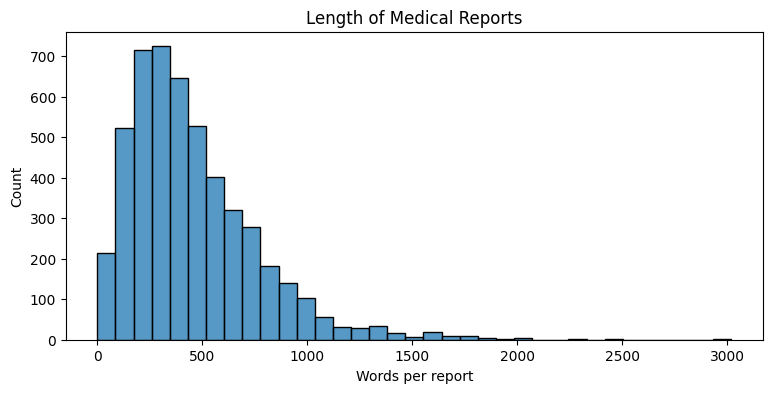

,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166


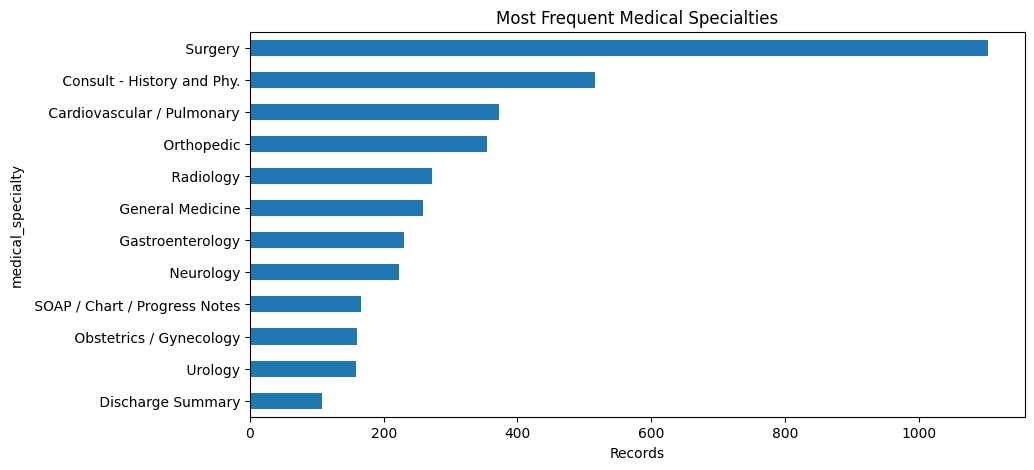

In [14]:
# B7–B9: text EDA

if medical_text is not None:
    plt.figure(figsize=(9, 4))
    sns.histplot(medical_text["word_count"], bins=35)
    plt.title("Length of Medical Reports")
    plt.xlabel("Words per report")
    plt.show()

    if specialty_col is not None:
        top_specialties = medical_text[specialty_col].value_counts().head(12)
        display(top_specialties)

        plt.figure(figsize=(10, 5))
        top_specialties.sort_values().plot(kind="barh")
        plt.title("Most Frequent Medical Specialties")
        plt.xlabel("Records")
        plt.show()


In [15]:
# B10–B12: tokenization, vocabulary and integer sequences

if medical_text is not None:
    medical_text["tokens"] = medical_text["clean_text"].str.split()

    vocabulary = Counter()
    for row_tokens in medical_text["tokens"]:
        vocabulary.update(row_tokens)

    print("Vocabulary size:", len(vocabulary))
    print("Most common terms:", vocabulary.most_common(20))

    vocab_limit = 8000
    max_len = 80

    word_to_index = {"<PAD>": 0, "<UNK>": 1}
    for idx, (word, _) in enumerate(vocabulary.most_common(vocab_limit - 2), start=2):
        word_to_index[word] = idx

    def encode_tokens(tokens):
        ids = [word_to_index.get(token, 1) for token in tokens[:max_len]]
        return ids + [0] * (max_len - len(ids))

    medical_text["encoded"] = medical_text["tokens"].map(encode_tokens)
    text_matrix = np.asarray(medical_text["encoded"].tolist(), dtype=np.int32)

    print("Encoded matrix:", text_matrix.shape)
    print("First sequence:", text_matrix[0][:25] if len(text_matrix) else "No records")


Vocabulary size: 20966
Most common terms: [('the', 149859), ('and', 82415), ('was', 65472), ('of', 59158), ('to', 50419), ('a', 43217), ('with', 35684), ('in', 32569), ('is', 23046), ('no', 17874), ('she', 17591), ('for', 16982), ('he', 15540), ('were', 15532), ('on', 14617), ('this', 13944), ('at', 13452), ('then', 12369), ('right', 11582), ('left', 11229)]
Encoded matrix: (4999, 80)
First sequence: [1104   17   69   71  277  194  774    8  463    5  197   12   67    6
   47  197  203   12 5421    9    1   54   12 2854  246]


In [16]:
# C1–C4: acquire image dataset and build a file/label table

try:
    xray_root = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
    image_paths = []
    for pattern in ("*.jpeg", "*.jpg", "*.png"):
        image_paths.extend(glob.glob(os.path.join(xray_root, "**", pattern), recursive=True))
except Exception as exc:
    xray_root = None
    image_paths = []
    print("X-ray dataset could not be downloaded.")
    print("Reason:", exc)

def infer_label(path):
    lower = path.lower()
    if "pneumonia" in lower:
        return "PNEUMONIA"
    if "normal" in lower:
        return "NORMAL"
    return "UNKNOWN"

if image_paths:
    xray_index = pd.DataFrame({
        "path": image_paths,
        "label": [infer_label(p) for p in image_paths]
    })
    xray_index = xray_index[xray_index["label"] != "UNKNOWN"].reset_index(drop=True)

    print("Images:", len(xray_index))
    display(xray_index["label"].value_counts())


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Images: 11712


,count
label,
PNEUMONIA,11712


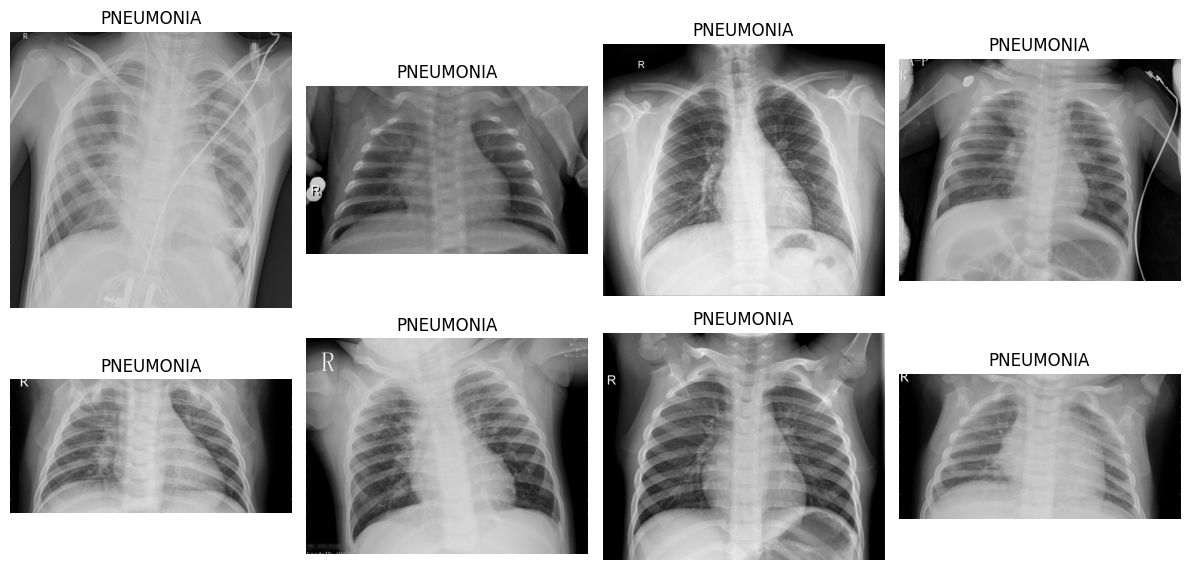

Sample dimensions: [(1512, 1488), (1148, 689), (2721, 2438), (1424, 1128), (1224, 584), (1448, 1112), (1932, 1561), (1224, 632)]
EXIF fields in sampled image: 0


In [17]:
# C5–C7: image EDA, dimensions and metadata check

if image_paths and len(xray_index):
    sample = xray_index.sample(min(8, len(xray_index)), random_state=7)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
        with Image.open(row["path"]) as img:
            ax.imshow(img.convert("L"), cmap="gray")
        ax.set_title(row["label"])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    dimensions = []
    for path in sample["path"]:
        try:
            with Image.open(path) as img:
                dimensions.append(img.size)
        except Exception:
            pass

    print("Sample dimensions:", dimensions)

    with Image.open(sample.iloc[0]["path"]) as test_img:
        exif = test_img.getexif()
        print("EXIF fields in sampled image:", len(exif))


In [18]:
# C8: image preprocessing

TARGET_SIZE = (224, 224)

def prepare_xray(path):
    with Image.open(path) as img:
        gray = img.convert("L")
        resized = gray.resize(TARGET_SIZE)
        array = np.asarray(resized, dtype=np.float32) / 255.0
    return array[..., None]

if image_paths and len(xray_index):
    chosen = xray_index.sample(min(16, len(xray_index)), random_state=7)
    prepared = np.stack([prepare_xray(p) for p in chosen["path"]])

    print("Tensor shape:", prepared.shape)
    print("Pixel range:", prepared.min(), "to", prepared.max())


Tensor shape: (16, 224, 224, 1)
Pixel range: 0.0 to 1.0


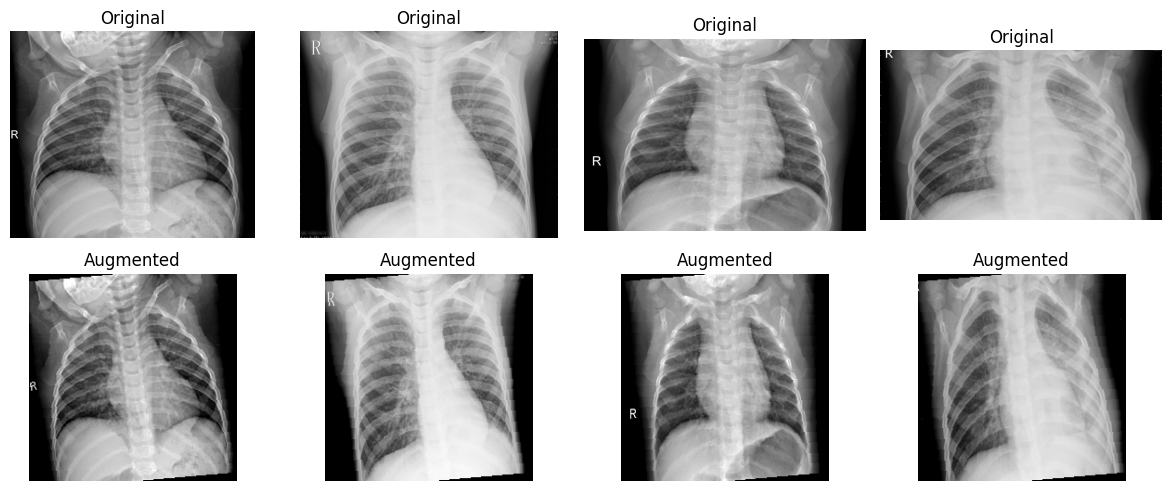

In [19]:
# C9: lightweight augmentation without a neural-network training pipeline

def augment_xray(path):
    with Image.open(path) as img:
        img = img.convert("L").resize(TARGET_SIZE)
        brighter = ImageEnhance.Contrast(img).enhance(1.15)
        shifted = brighter.rotate(5)
        return np.asarray(shifted, dtype=np.float32) / 255.0

if image_paths and len(xray_index):
    aug_sample = xray_index.sample(min(4, len(xray_index)), random_state=11)

    fig, axes = plt.subplots(2, len(aug_sample), figsize=(12, 5))
    for j, (_, row) in enumerate(aug_sample.iterrows()):
        with Image.open(row["path"]) as original:
            axes[0, j].imshow(original.convert("L"), cmap="gray")
        axes[0, j].set_title("Original")
        axes[0, j].axis("off")

        axes[1, j].imshow(augment_xray(row["path"]), cmap="gray")
        axes[1, j].set_title("Augmented")
        axes[1, j].axis("off")

    plt.tight_layout()
    plt.show()


In [20]:
# C10: save clean image-only copies

if image_paths and len(xray_index):
    export_dir = "/content/medical_multimodal_lab/clean_xrays"
    os.makedirs(export_dir, exist_ok=True)

    for i, path in enumerate(xray_index["path"].head(10)):
        with Image.open(path) as img:
            img.convert("L").save(os.path.join(export_dir, f"xray_{i:02d}.png"))

    print("Clean copies saved in:", export_dir)
    print("Re-saving as PNG creates a new image file without carrying over the source EXIF block.")


Clean copies saved in: /content/medical_multimodal_lab/clean_xrays
Re-saving as PNG creates a new image file without carrying over the source EXIF block.


In [21]:
# D1–D3: load one MIT-BIH record

record_name = "100"

try:
    ecg_record = wfdb.rdrecord(record_name, pn_dir="mitdb")
    ecg_annotations = wfdb.rdann(record_name, "atr", pn_dir="mitdb")
except Exception as exc:
    ecg_record = None
    ecg_annotations = None
    print("MIT-BIH record could not be loaded.")
    print("Reason:", exc)

if ecg_record is not None:
    fs = ecg_record.fs
    ecg = ecg_record.p_signal[:, 0]

    print("Sampling rate:", fs, "Hz")
    print("Samples:", len(ecg))
    print("Channels:", ecg_record.n_sig)
    print("Signal names:", ecg_record.sig_name)


Sampling rate: 360 Hz
Samples: 650000
Channels: 2
Signal names: ['MLII', 'V5']


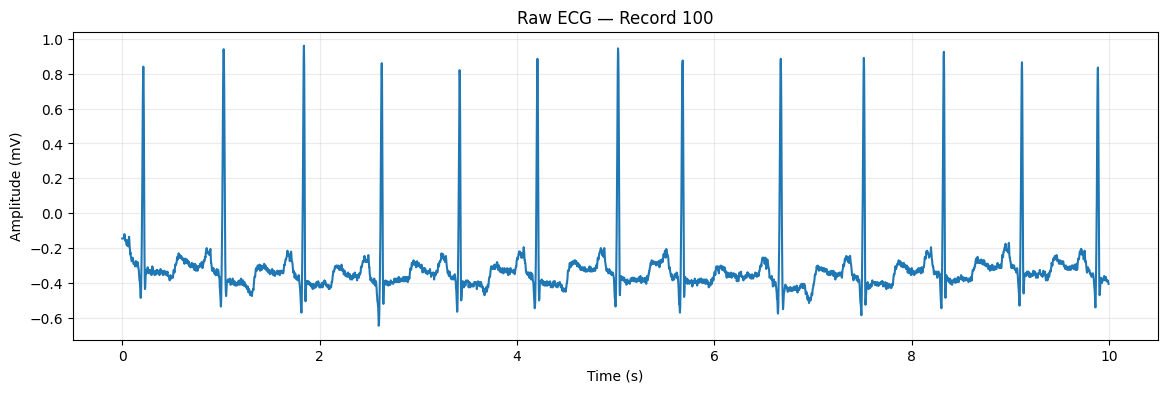

In [22]:
# D4: raw ECG visualization

if ecg_record is not None:
    seconds = 10
    n = min(int(seconds * fs), len(ecg))
    t = np.arange(n) / fs

    plt.figure(figsize=(14, 4))
    plt.plot(t, ecg[:n])
    plt.title("Raw ECG — Record 100")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(alpha=0.25)
    plt.show()


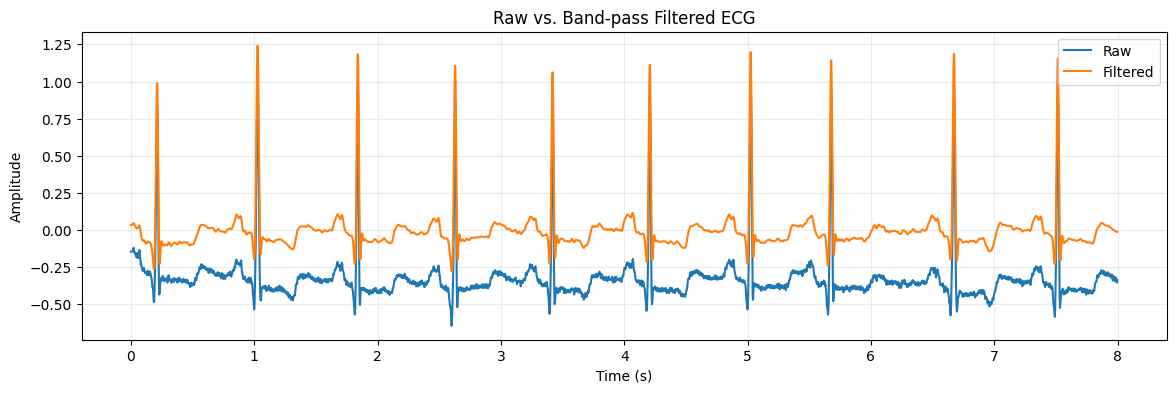

In [23]:
# D5–D6: band-pass filtering using second-order sections

def clean_ecg(x, sampling_rate, low=0.5, high=40):
    sos = signal.butter(
        4,
        [low, high],
        btype="bandpass",
        fs=sampling_rate,
        output="sos"
    )
    return signal.sosfiltfilt(sos, x)

if ecg_record is not None:
    filtered = clean_ecg(ecg, fs)

    n = min(int(8 * fs), len(ecg))
    t = np.arange(n) / fs

    plt.figure(figsize=(14, 4))
    plt.plot(t, ecg[:n], label="Raw")
    plt.plot(t, filtered[:n], label="Filtered")
    plt.title("Raw vs. Band-pass Filtered ECG")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


Standardized mean: 0.0
Standardized std: 1.0
Window array: (902, 720)


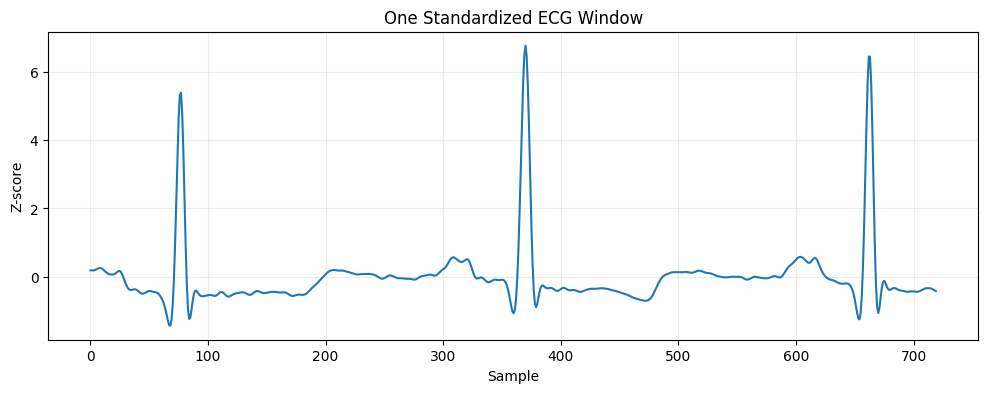

In [24]:
# D7–D9: standardization and fixed-length segmentation

if ecg_record is not None:
    standardized = StandardScaler().fit_transform(filtered.reshape(-1, 1)).ravel()

    window_seconds = 2
    samples_per_window = int(window_seconds * fs)
    usable = (len(standardized) // samples_per_window) * samples_per_window

    windows = standardized[:usable].reshape(-1, samples_per_window)

    print("Standardized mean:", round(float(standardized.mean()), 6))
    print("Standardized std:", round(float(standardized.std()), 6))
    print("Window array:", windows.shape)

    plt.figure(figsize=(12, 4))
    plt.plot(windows[0])
    plt.title("One Standardized ECG Window")
    plt.xlabel("Sample")
    plt.ylabel("Z-score")
    plt.grid(alpha=0.25)
    plt.show()


In [25]:
# D10: statistical features from ECG windows

if ecg_record is not None:
    rows = []

    for w in windows[:100]:
        rows.append({
            "mean": np.mean(w),
            "std": np.std(w),
            "median": np.median(w),
            "minimum": np.min(w),
            "maximum": np.max(w),
            "range": np.ptp(w),
            "rms": np.sqrt(np.mean(w ** 2)),
            "energy": np.mean(w ** 2),
            "skewness": stats.skew(w),
            "kurtosis": stats.kurtosis(w),
        })

    ecg_features = pd.DataFrame(rows)
    display(ecg_features.head())


,mean,std,median,minimum,maximum,range,rms,energy,skewness,kurtosis
0,-0.012334,0.998229,-0.104618,-1.444392,6.779481,8.223873,0.998306,0.996614,4.468889,22.800829
1,-0.030419,0.762288,-0.107255,-1.522750,6.037500,7.560250,0.762895,0.582008,5.294164,34.533013
2,0.001006,0.982075,-0.205090,-1.323744,6.544627,7.868371,0.982075,0.964472,4.486722,22.729551
3,0.004138,0.841257,-0.054952,-1.253789,6.482400,7.736189,0.841268,0.707731,5.288694,33.163041
4,0.032746,0.907645,-0.092603,-1.324666,6.191349,7.516015,0.908236,0.824892,4.582337,23.938419


Detected peaks: 2276


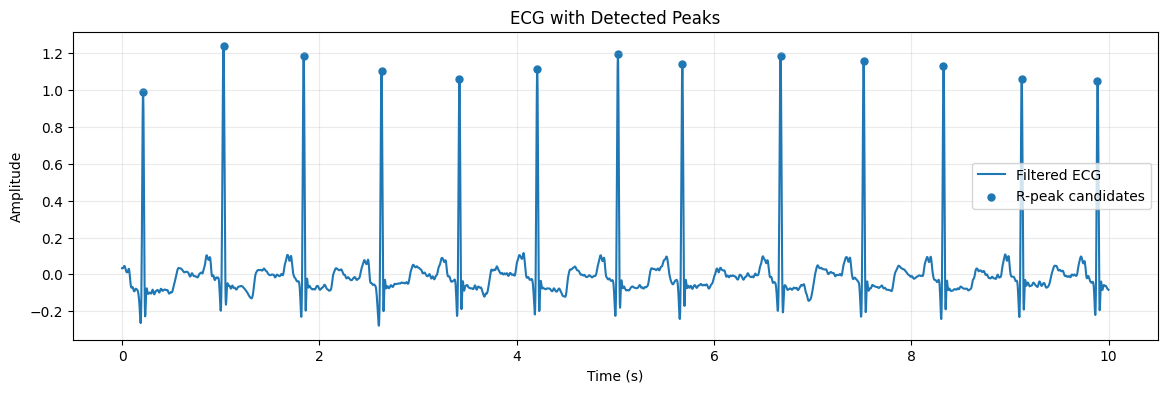

In [26]:
# D11–D12: R-peak detection

if ecg_record is not None:
    peak_distance = int(0.25 * fs)

    peaks, peak_info = signal.find_peaks(
        filtered,
        distance=peak_distance,
        prominence=0.3
    )

    print("Detected peaks:", len(peaks))

    n = min(int(10 * fs), len(filtered))
    visible_peaks = peaks[peaks < n]
    t = np.arange(n) / fs

    plt.figure(figsize=(14, 4))
    plt.plot(t, filtered[:n], label="Filtered ECG")
    plt.scatter(
        visible_peaks / fs,
        filtered[visible_peaks],
        s=25,
        label="R-peak candidates"
    )
    plt.title("ECG with Detected Peaks")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


In [27]:
# D13: heart-rate estimation from successive peak intervals

if ecg_record is not None and len(peaks) > 1:
    rr_seconds = np.diff(peaks) / fs
    mean_rr = np.mean(rr_seconds)

    bpm = 60 / mean_rr if mean_rr > 0 else np.nan

    print("Mean RR interval:", round(float(mean_rr), 4), "seconds")
    print("Estimated heart rate:", round(float(bpm), 2), "BPM")


Mean RR interval: 0.7935 seconds
Estimated heart rate: 75.61 BPM


## Final observations

This lab demonstrates that healthcare data needs modality-specific preprocessing:

1. **Tabular:** zero-as-missing handling, imputation, statistical tests, scaling and class balancing.
2. **Text:** normalization, identifier-pattern removal, tokenization and numerical encoding.
3. **Images:** grayscale conversion, resizing, normalization, augmentation and metadata-aware export.
4. **Signals:** filtering, standardization, segmentation, feature extraction and peak-based heart-rate estimation.

The preprocessing stage is important because medical datasets can contain missing measurements, sensitive information, acquisition noise, heterogeneous formats and imbalanced classes.
